# Refactored piezo patch optimizer runner

This notebook is intentionally thin: define physical parameters/settings, run the standalone optimizer, then plot/post-process results.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Edit this if needed so Python can find Modeling/.
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

from Modeling.models_fish.FE_helpers_fish import *
from Modeling.models_fish.beam_properties_fish import *
from Modeling.models_fish.piezo_patch_optimizer import *
from Modeling.models_fish.piezo_plotting import *
from Modeling.models_fish.piezo_experiment_runner import *

In [3]:
L = 0.4
b_s = 84e-3       # substrate width [m]
b_p = 62e-3       # active piezo width [m]
h_s = 0.504e-3     # substrate thickness [m]
h_p = 0.3e-3     # one piezo layer thickness [m]
E_s = 3.0e9       # substrate Young's modulus [Pa]
E_p = 31.0e9      # piezo Young's modulus [Pa]
rho_s = 1190.0    # substrate density [kg/m^3]
rho_p = 7800.0    # piezo density [kg/m^3]

# Bare substrate section
EI_substrate = b_s * E_s * h_s**3 / 12.0
rhoA_substrate = b_s * rho_s * h_s

# Active piezo-covered section: substrate + symmetric piezo layers
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(
    E_layers=[E_s, E_p],
    rho_layers=[rho_s, rho_p],
    h_layers=[h_s, h_p],
    b_layers=[b_s, b_p],
)

# build_geometry_from_types accepts optional 'h' for mesh size.
region_types = {
    "piezo":     {"EI": EI_piezo,     "rhoA": rhoA_piezo,     "h": 1.0e-3},
    "substrate": {"EI": EI_substrate, "rhoA": rhoA_substrate, "h": 1.0e-3},
}

print("Region properties:")
for name, props in region_types.items():
    print(f"  {name:10s}: EI = {props['EI']:.4e} N m^2, rhoA = {props['rhoA']:.4e} kg/m")

base_params = PiezoBeamParams(
    b=b_p,              # active piezo width used in theta_mech
    hp=h_p,
    hs=h_s,
    rho_p=rho_p,
    rho_s=rho_s,
    E_s=E_s,
    s11=1.0 / E_p,      # approximate piezo compliance from E_p
    d31=-1.48e-10,
    eps_r=1700.0,
    omega_p=2*np.pi*1.0,
    omega_q=2*np.pi*100.0,
)

# Damping calibration values. Edit these to match COMSOL/experiment.
base_params.zeta_p = 0.05
base_params.zeta_q = 0.20

print("theta_mech =", base_params.theta_mech)
print("Cp_scalar  =", base_params.Cp_scalar)
print("Rayleigh c_alpha, c_beta =", base_params.c_alpha, base_params.c_beta)


Region properties:
  piezo     : EI = 1.9770e-01 N m^2, rhoA = 3.4054e-01 kg/m
  substrate : EI = 2.6885e-03 N m^2, rhoA = 5.0380e-02 kg/m
theta_mech = -0.000228702624
Cp_scalar  = 5.940747413333333e-08
Rayleigh c_alpha, c_beta = 0.19746967160981108 0.000125109962954609


In [ ]:
geom_settings = GeometrySettings(
    Np=3,
    patch_length_bounds=(10e-3, 80e-3),
    gap_bounds=(3e-3, 40e-3),
    tip_substrate_bounds=(0.0, L),
)

circuit_settings = CircuitSettings(R_c=1e3, K_p=0.02, K_i=0.0, K_c=0.0)

opt_settings = OptimizerSettings(
    method="differential_evolution",
    maxiter=10,
    popsize=7,
    seed=2,
    polish=False,
    workers=1,
    n_random_samples=250,
    powell_maxiter=80,
)

# Single-mode example
# objective_settings = ObjectiveSettings(
#     objective="single_mode",
#     single_mode_number=3,
#     phase_mode="binary",
#     output="tip",
#     voltage_amplitude=1.0,
#     final_sweep_range_hz=(0.1, 40.0),
#     final_sweep_n_freq=1000,
# )

# Multi-mode example with automatic single-mode score normalizers.
# objective_settings = ObjectiveSettings(
#     objective="multi_mode",
#     multi_mode_numbers=(1, 2, 3),
#     multi_mode_weights=(1, 1, 1),
#     multi_mode_reduction="weighted_sum",        # maximize the weakest normalized mode
#     phase_mode="continuous",
#     output="tip",
#     voltage_amplitude=1.0,
#     final_sweep_range_hz=(0.1, 40.0),
#     final_sweep_n_freq=1000,
# )

# Traveling-wave example: uncomment this block instead of the multi-mode block above.
objective_settings = ObjectiveSettings(
    objective="traveling_wave",
    phase_mode="continuous",
    output="tip",  # retained for compatibility; traveling_wave uses traveling_wave_settings
    voltage_amplitude=1.0,
    traveling_wave_settings={
        "mode_pair": (1, 2),
        "frequency_fraction": 0.5,      # halfway between the two mode frequencies
        # "frequency_hz": 5.0,          # use this instead of mode_pair if desired
        "amplitude_reference": 1e-4,    # A_ref in A_rms / (A_ref + A_rms)
        "ti_power": 2.0,
        "amplitude_power": 1.0,
        "envelope_power": 1.0,
        "x_fraction_bounds": (0.05, 1.0),
        "direction": "either",         # "positive_x"/"tailward" or "negative_x"/"headward"
    },
    continuous_phase_n_starts=16,
    final_sweep_range_hz=(0.1, 40.0),
    final_sweep_n_freq=1000,
)


optimizer = PiezoPatchOptimizer(
    L=L,
    region_types=region_types,
    base_params=base_params,
    geometry_settings=geom_settings,
    objective_settings=objective_settings,
    circuit_settings=circuit_settings,
    optimizer_settings=opt_settings,
)

# Run one single-mode optimization per target mode. Each best score becomes
# that mode's normalizer, so the final multi-mode objective works with
# fractions of each mode's own best achievable response.
# normalizer_info = optimizer.calibrate_multimode_score_normalizers(
#     apply=True,
#     verbose=True,
# )
# print("Auto normalizers:", normalizer_info["normalizers"])
# print("Single-mode calibration scores:", normalizer_info["scores"])

result = optimizer.run()
best = optimizer.inspect_result(result)

print("Best score:", best["inner"]["score"])
print("Objective:", best["inner"]["objective"])
print("Frequencies [Hz]:", best["inner"]["freq_hz"])
print("Best design [mm]:", 1e3 * result.x)
print("Patch xL [mm]:", 1e3 * best["layout"]["xL"])
print("Patch xR [mm]:", 1e3 * best["layout"]["xR"])
print("Raw mode scores:", best["inner"].get("raw_mode_scores"))
print("Normalized mode scores:", best["inner"].get("normalized_mode_scores"))
print("Weighted mode scores:", best["inner"].get("weighted_mode_scores"))
print("Phase [deg]:", best["inner"]["phase_deg"])

if best["inner"]["objective"] == "traveling_wave":
    tw = best["inner"]["traveling_wave_metrics"]
    print("Traveling index:", tw["traveling_index"])
    print("RMS amplitude:", tw["amplitude_rms"])
    print("Amplitude score:", tw["amplitude_score"])
    print("Envelope CV:", tw["envelope_cv"])
    print("Envelope score:", tw["envelope_score"])
    print("Phase slope [rad/m]:", tw["phase_slope_rad_per_m"])


differential_evolution step 1: f(x)= -0.012863984812735938
differential_evolution step 2: f(x)= -0.012863984812735938
differential_evolution step 3: f(x)= -0.013460307231705859
differential_evolution step 4: f(x)= -0.014710799784401873
differential_evolution step 5: f(x)= -0.014710799784401873
differential_evolution step 6: f(x)= -0.017718350672703925
differential_evolution step 7: f(x)= -0.018735048860579077
differential_evolution step 8: f(x)= -0.019464541264737588
differential_evolution step 9: f(x)= -0.019464541264737588
differential_evolution step 10: f(x)= -0.019464541264737588
Best score: 0.019464541264737588
Objective: traveling_wave
Frequencies [Hz]: 2.914813393276413
Best design [mm]: [24.62682552 38.55167302 79.9260588 ]
Patch xL [mm]: [ 0.         63.17849854]
Patch xR [mm]: [ 24.62682552 143.10455734]
Raw mode scores: None
Normalized mode scores: None
Weighted mode scores: None
Phase [deg]: [  0.        115.2710027]
Traveling index: 0.9447704483514948
RMS amplitude: 3.2170

Plotting optimizer result
Objective: traveling_wave
Total score: 0.019464541264737588
Output: traveling_wave
Phase mode: continuous
Patch xL [mm]: [ 0.         63.17849854]
Patch xR [mm]: [ 24.62682552 143.10455734]


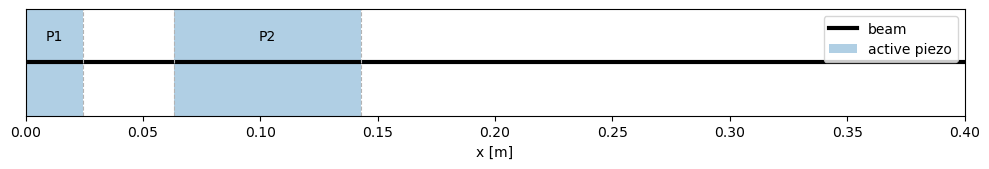

In [28]:
plot_optimizer_result(
    optimizer=optimizer,
    best=best,
    L=L,
    mode="all",
)

In [6]:
# ============================================================
# Plotting helpers for new single-mode / multi-mode optimizer
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

try:
    from Modeling.models_fish.piezo_plotting import (
        plot_layout,
        plot_metric_frf,
        plot_all_binary_frf,
        plot_all_binary_bar,
        plot_patch_phases,
        plot_phase_phasors,
        plot_mode_shape_and_curvature,
        plot_multimode_phase_matrix,
        plot_multimode_score_bar,
    )
except Exception:
    from piezo_plotting import (
        plot_layout,
        plot_metric_frf,
        plot_all_binary_frf,
        plot_all_binary_bar,
        plot_patch_phases,
        plot_phase_phasors,
        plot_mode_shape_and_curvature,
    )
    # These only exist in the newer multimode plotting file.
    try:
        from piezo_plotting import plot_multimode_phase_matrix, plot_multimode_score_bar
    except Exception:
        plot_multimode_phase_matrix = None
        plot_multimode_score_bar = None


def _is_multimode_inner(inner: dict) -> bool:
    """Return True if inner result is from objective='multi_mode'."""
    return inner.get("objective", "single_mode") == "multi_mode"


def _mode_results_from_inner(inner: dict) -> list[dict]:
    """Always return a list of mode result dictionaries."""
    if "mode_results" in inner and inner["mode_results"] is not None:
        return list(inner["mode_results"])
    return [inner]


def _select_mode_results(inner: dict, mode="all") -> list[dict]:
    """
    Select which mode result(s) to plot.

    mode options:
        "all"       -> plot all modes
        0, 1, 2     -> plot by mode_result list index
        mode number -> plot by actual mode_number, if found
    """
    mode_results = _mode_results_from_inner(inner)

    if mode == "all":
        return mode_results

    # First try list index.
    if isinstance(mode, int):
        if 0 <= mode < len(mode_results):
            return [mode_results[mode]]

        # Otherwise try actual mode number.
        matches = [r for r in mode_results if int(r.get("mode_number", -999)) == int(mode)]
        if matches:
            return matches

    raise ValueError(
        f"Could not select mode={mode}. Use 'all', a mode_result index, or an actual mode_number."
    )


def plot_optimizer_result(
    *,
    optimizer,
    best: dict,
    L: float,
    mode="all",
    plot_layout_flag=True,
    plot_phase_flag=True,
    plot_frf_flag=True,
    plot_binary_flag=True,
    plot_curvature_flag=True,
    plot_multimode_summary=True,
    show=True,
):
    """
    Plot one completed optimizer result.

    Parameters
    ----------
    optimizer:
        PiezoPatchOptimizer instance.
    best:
        Dictionary from optimizer.inspect_result(result), or record["best"].
    L:
        Total beam length.
    mode:
        "all", an index into mode_results, or an actual mode number.
    """

    layout = best["layout"]
    inner = best["inner"]
    fe = best["fe"]

    mode_results = _select_mode_results(inner, mode=mode)
    is_multi = _is_multimode_inner(inner)

    print("=" * 80)
    print("Plotting optimizer result")
    print("Objective:", inner.get("objective", "single_mode"))
    print("Total score:", inner.get("score"))
    print("Output:", inner.get("output", None))
    print("Phase mode:", inner.get("phase_mode", None))
    print("Patch xL [mm]:", 1e3 * np.asarray(layout["xL"]))
    print("Patch xR [mm]:", 1e3 * np.asarray(layout["xR"]))

    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------
    if plot_layout_flag:
        plot_layout(layout, L)

    # --------------------------------------------------------
    # Multimode summary plots
    # --------------------------------------------------------
    if is_multi and plot_multimode_summary:
        if plot_multimode_score_bar is not None:
            plot_multimode_score_bar(inner)
        else:
            print("plot_multimode_score_bar is not available in the imported plotting file.")

        if plot_multimode_phase_matrix is not None:
            plot_multimode_phase_matrix(inner, relative=True)
        else:
            print("plot_multimode_phase_matrix is not available in the imported plotting file.")

    # --------------------------------------------------------
    # Per-mode plots
    # --------------------------------------------------------
    for mode_result in mode_results:
        mode_number = int(mode_result.get("mode_number", mode_result.get("target_mode_number", 1)))
        freq_hz = float(mode_result["freq_hz"])

        print("-" * 80)
        print(f"Mode {mode_number}")
        print(f"Natural frequency [Hz]: {freq_hz:.6g}")
        print(f"Mode score: {mode_result['score']:.6e}")
        print("Phase [deg]:", np.asarray(mode_result.get("phase_deg", [])))
        print("Relative phase [deg]:", np.asarray(mode_result.get("relative_phase_deg", [])))

        # ----------------------------------------------------
        # Phase plots
        # ----------------------------------------------------
        if plot_phase_flag:
            plot_patch_phases(
                layout,
                phase_deg=mode_result["relative_phase_deg"],
            )

            plot_phase_phasors(
                voltage_vector=mode_result["voltage_vector"],
            )

        # ----------------------------------------------------
        # Best FRF for this mode's optimized phase vector
        # ----------------------------------------------------
        if plot_frf_flag:
            if hasattr(optimizer, "dense_metric_frf_for_mode_result"):
                best_frf = optimizer.dense_metric_frf_for_mode_result(
                    fe,
                    mode_result,
                )
            else:
                best_frf = optimizer.dense_metric_frf_for_plot(
                    fe,
                    mode_result["voltage_vector"],
                    output=mode_result.get("output", inner.get("output", "tip")),
                )

            plot_metric_frf(
                best_frf,
                natural_freq_hz=freq_hz,
                label=f"mode {mode_number} optimized phase",
            )

        # ----------------------------------------------------
        # Binary-only comparison plots
        # ----------------------------------------------------
        if plot_binary_flag and mode_result.get("phase_mode", inner.get("phase_mode")) == "binary":
            all_binary = optimizer.dense_all_binary_metric_frf_for_plot(
                fe,
                output=mode_result.get("output", inner.get("output", "tip")),
            )

            plot_all_binary_frf(
                all_binary,
                natural_freq_hz=freq_hz,
                use_metric=True,
            )

            if mode_result.get("all_phase_results", None) is not None:
                plot_all_binary_bar(mode_result["all_phase_results"])

        # ----------------------------------------------------
        # Mode shape + curvature plot
        # ----------------------------------------------------
        if plot_curvature_flag:
            plot_mode_shape_and_curvature(
                fe,
                layout,
                mode_number=mode_number,
            )

    if show:
        plt.show()


def plot_record(
    record: dict,
    L: float,
    mode="all",
    **kwargs,
):
    """
    Plot directly from a sweep record returned by run_sweep(...).

    Example:
        plot_record(records[0], L=L)
        plot_record(records[3], L=L, mode=2)
    """
    return plot_optimizer_result(
        optimizer=record["optimizer"],
        best=record["best"],
        L=L,
        mode=mode,
        **kwargs,
    )


def plot_after_optimization(
    optimizer,
    result,
    L: float,
    mode="all",
    **kwargs,
):
    """
    Manually plot after optimization is complete.

    Example:
        result = optimizer.run()
        plot_after_optimization(optimizer, result, L=L)

    This rebuilds the best FE model using optimizer.inspect_result(result).
    """
    best = optimizer.inspect_result(result)
    return plot_optimizer_result(
        optimizer=optimizer,
        best=best,
        L=L,
        mode=mode,
        **kwargs,
    )